# Sadeed_Tashkeela — EDA

Exploratory analysis of `datasets/Sadeed_Tashkeela/{train,test}.csv` (raw
output of `scripts/prepare_sadeed_tashkeela.py`), ahead of building the
training-ready preprocessing step (`scripts/preprocess_sadeed_tashkeela.py`).

Columns: `filename` (source book), `output` (diacritized Arabic text),
`input` (the same text with diacritics stripped).

`train.csv` is ~1.3GB / 3.5M rows — too big to load in full with plain
`pd.read_csv()`. Every full-corpus statistic below is computed with a single
streamed pass; only a small in-memory sample is used for plotting/inspection.


In [ ]:
from collections import Counter
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pyarabic import araby

# notebooks -> repo root
DATASET_DIR = Path("../datasets/Sadeed_Tashkeela")
TRAIN_PATH = DATASET_DIR / "train.csv"
TEST_PATH = DATASET_DIR / "test.csv"

CHUNKSIZE = 50_000
SAMPLE_SIZE = 100_000
MISMATCH_SAMPLE_SIZE = 50
RANDOM_SEED = 42

rng = np.random.default_rng(RANDOM_SEED)

TASHKEEL = set(araby.TASHKEEL)

## Streaming + sampling helpers

- `iter_chunks` streams the CSV in fixed-size chunks via a real CSV parser
  (rows contain embedded newlines inside quoted fields, so naive
  line-splitting would corrupt records). `keep_default_na=False` stops empty
  strings from being silently coerced to `NaN` — detecting empty rows is
  itself one of the things we're checking for.
- `build_sample` draws a uniform random sample across the whole file
  (chunk-wise sampling, concatenated) for anything that needs full pandas
  ergonomics: plotting, `.head()`, manual spot checks.


In [2]:
def iter_chunks(path, usecols=None, chunksize=CHUNKSIZE):
    return pd.read_csv(
        path, chunksize=chunksize, dtype=str, keep_default_na=False, usecols=usecols
    )


def count_rows(path, chunksize=CHUNKSIZE):
    """Row count via the real CSV parser — rows can span multiple physical
    lines (quoted fields with embedded newlines), so counting lines directly
    would overcount."""
    return sum(len(chunk) for chunk in iter_chunks(path, usecols=["filename"], chunksize=chunksize))


def build_sample(path, sample_size=SAMPLE_SIZE, chunksize=CHUNKSIZE):
    """Uniform-ish random sample: keep a random fraction of every chunk, then
    trim/pad to sample_size. Good enough for plotting/inspection purposes."""
    n_rows = count_rows(path, chunksize=chunksize)
    frac = min(1.0, (sample_size * 1.2) / max(n_rows, 1))

    parts = []
    for chunk in iter_chunks(path, chunksize=chunksize):
        if frac >= 1.0:
            parts.append(chunk)
        else:
            mask = rng.random(len(chunk)) < frac
            parts.append(chunk[mask])

    sample = pd.concat(parts, ignore_index=True)
    if len(sample) > sample_size:
        sample = sample.sample(n=sample_size, random_state=RANDOM_SEED).reset_index(drop=True)
    return sample


test_df = pd.read_csv(TEST_PATH, dtype=str, keep_default_na=False)
train_sample = build_sample(TRAIN_PATH)
print(f"test.csv loaded in full: {len(test_df):,} rows")
print(f"train.csv sample built: {len(train_sample):,} rows")


test.csv loaded in full: 2,485 rows
train.csv sample built: 100,000 rows


## 1. Schema & sanity checks

In [3]:
print("test.csv columns:", list(test_df.columns))
print("train sample columns:", list(train_sample.columns))
print()
print("test.csv dtypes:\n", test_df.dtypes)
print()
display(train_sample.head())


test.csv columns: ['filename', 'output', 'input']
train sample columns: ['filename', 'output', 'input']

test.csv dtypes:
 filename    str
output      str
input       str
dtype: object



,filename,output,input
0,شرح البهجة الوردية.txt,فِي الرَّوْضِ (فَرْعٌ) .\nرَجُلَانِ بَيْنَهُمَ...,في الروض (فرع) .\nرجلان بينهما أربعون شاة مختل...
1,السنن الكبرى للبيهقي وفي ذيله الجوهر النقي.txt,ثُمَّ غَسَلَ وَجْهَهُ ثَلَاثًا وَيَدَهُ الْيُم...,ثم غسل وجهه ثلاثا ويده اليمنى ثلاثا، والأخرى ث...
2,التلخيص الحبير في تخريج أحاديث الرافعي الكبير...,عَنْ أَبِيهِ، وَمَكْحُولٍ كِلَاهُمَا عَنْ عَمْ...,عن أبيه، ومكحول كلاهما عن عمرو بن شعيب، عن أبي...
3,نهاية المحتاج إلى شرح المنهاج.txt,وَمَا اخْتَارَهُ الْأَذْرَعِيُّ) أَيْ مِنْ حَي...,وما اختاره الأذرعي) أي من حيث الدليل (قوله: وأ...
4,رد المحتار.txt,فَلَا فَرْقَ بَيْنَ النَّفْلِ وَسُنَنِ الزَّوَ...,فلا فرق بين النفل وسنن الزوائد من حيث الحكم؛ ل...


In [4]:
def schema_pass(path):
    n_rows = 0
    n_null = {"filename": 0, "output": 0, "input": 0}
    n_empty = {"filename": 0, "output": 0, "input": 0}

    for chunk in iter_chunks(path):
        n_rows += len(chunk)
        for col in n_null:
            n_null[col] += chunk[col].isna().sum()
            n_empty[col] += (chunk[col].fillna("").str.strip() == "").sum()

    return n_rows, n_null, n_empty


train_n_rows, train_n_null, train_n_empty = schema_pass(TRAIN_PATH)
print(f"train.csv: {train_n_rows:,} rows")
print(f"  null counts:  {train_n_null}")
print(f"  empty counts: {train_n_empty}")


train.csv: 1,042,698 rows
  null counts:  {'filename': np.int64(0), 'output': np.int64(0), 'input': np.int64(0)}
  empty counts: {'filename': np.int64(0), 'output': np.int64(1), 'input': np.int64(1)}


## 2. Consistency check: `input == strip_tashkeel(output)`

In [5]:
def consistency_pass(path, mismatch_sample_size=MISMATCH_SAMPLE_SIZE):
    n_match = 0
    n_mismatch = 0
    mismatches = []

    for chunk in iter_chunks(path):
        stripped = chunk["output"].map(araby.strip_tashkeel)
        match = stripped == chunk["input"]
        n_match += match.sum()
        n_mismatch += (~match).sum()

        if len(mismatches) < mismatch_sample_size:
            need = mismatch_sample_size - len(mismatches)
            bad_rows = chunk.loc[~match].head(need)
            for _, row in bad_rows.iterrows():
                mismatches.append(
                    {
                        "filename": row["filename"],
                        "output": row["output"][:120],
                        "input": row["input"][:120],
                        "stripped": araby.strip_tashkeel(row["output"])[:120],
                    }
                )

    return n_match, n_mismatch, mismatches


train_n_match, train_n_mismatch, train_mismatches = consistency_pass(TRAIN_PATH)
total = train_n_match + train_n_mismatch
print(f"match:    {train_n_match:,} ({train_n_match / total:.4%})")
print(f"mismatch: {train_n_mismatch:,} ({train_n_mismatch / total:.4%})")
display(pd.DataFrame(train_mismatches))


match:    1,042,698 (100.0000%)
mismatch: 0 (0.0000%)


""


## 3. Text length distributions

Char/word lengths across the *full* corpus (cheap — only lengths are kept in
memory, not the text itself), used to pick a `max_len` for preprocessing and
to sanity-check the submodule's `split_corpus` word-count range
(`DEF_RANGE_MIN=5`, `DEF_RANGE_MAX=40`).


In [6]:
def length_pass(path):
    char_lens = []
    word_lens = []

    for chunk in iter_chunks(path, usecols=["output"]):
        char_lens.append(chunk["output"].str.len().to_numpy())
        word_lens.append(chunk["output"].str.split().str.len().to_numpy())

    return np.concatenate(char_lens), np.concatenate(word_lens)


train_char_lens, train_word_lens = length_pass(TRAIN_PATH)

percentiles = [50, 90, 95, 99, 100]
char_pcts = np.percentile(train_char_lens, percentiles)
word_pcts = np.percentile(train_word_lens, percentiles)

print("char length percentiles:", dict(zip(percentiles, char_pcts.round(1))))
print("word length percentiles:", dict(zip(percentiles, word_pcts.round(1))))


char length percentiles: {50: np.float64(450.0), 90: np.float64(533.0), 95: np.float64(575.0), 99: np.float64(997.0), 100: np.float64(6451.0)}
word length percentiles: {50: np.float64(52.0), 90: np.float64(60.0), 95: np.float64(65.0), 99: np.float64(117.0), 100: np.float64(762.0)}


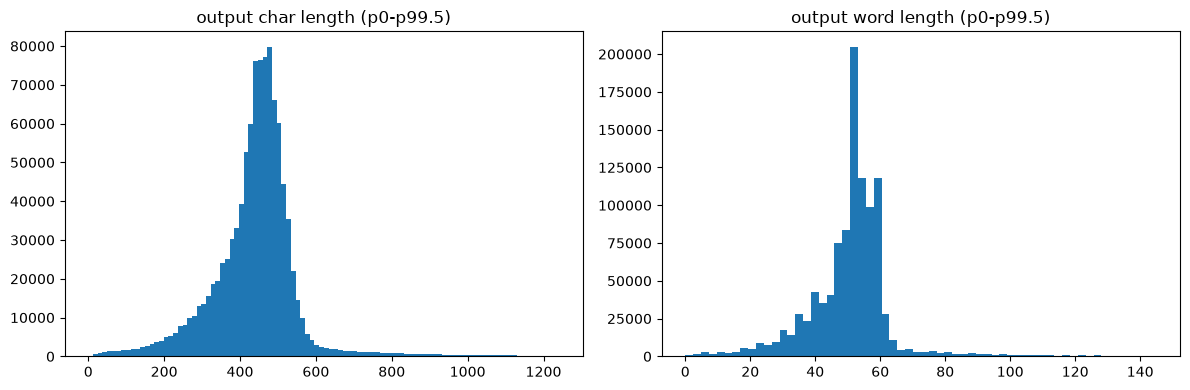

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(train_char_lens, bins=100, range=(0, np.percentile(train_char_lens, 99.5)))
axes[0].set_title("output char length (p0-p99.5)")
axes[1].hist(train_word_lens, bins=60, range=(0, np.percentile(train_word_lens, 99.5)))
axes[1].set_title("output word length (p0-p99.5)")
plt.tight_layout()
plt.show()


## 4. Character-level vocabulary

Full-corpus character frequency, split into the base-character vocab (from
`input`, diacritics already stripped) and any unexpected characters
(non-Arabic letters, digits, Latin, punctuation) — candidates for a
preprocessing allowlist.


In [8]:
def char_freq_pass(path):
    counter = Counter()
    for chunk in iter_chunks(path, usecols=["input"]):
        counter.update("".join(chunk["input"]))
    return counter


train_char_freq = char_freq_pass(TRAIN_PATH)
print(f"{len(train_char_freq):,} distinct characters in `input`")

char_freq_df = (
    pd.DataFrame(train_char_freq.items(), columns=["char", "count"])
    .sort_values("count", ascending=False)
    .reset_index(drop=True)
)
display(char_freq_df.head(20))


133 distinct characters in `input`


,char,count
0,,52331631
1,ا,28945734
2,ل,27234850
3,ي,13984720
4,م,13287377
5,و,12928398
6,ن,12187164
7,ه,10694514
8,ب,8541121
9,ر,8464177


In [9]:
def is_arabic_letter(ch):
    return "\u0600" <= ch <= "\u06FF"


char_freq_df["is_arabic_range"] = char_freq_df["char"].map(is_arabic_letter)
non_arabic = char_freq_df[~char_freq_df["is_arabic_range"] & (char_freq_df["char"] != " ")]
print(f"{len(non_arabic):,} distinct non-Arabic-range characters, "
      f"{non_arabic['count'].sum():,} total occurrences")
display(non_arabic.head(30))


92 distinct non-Arabic-range characters, 8,858,880 total occurrences


,char,count,is_arabic_range
30,),1419802,False
31,(,1411895,False
34,\n,1243216,False
35,.,976773,False
37,:,940727,False
41,/,385531,False
42,1,370478,False
44,2,287490,False
46,3,246124,False
47,4,230729,False


## 5. Diacritic mark frequency / class balance

Per-character diacritic distribution in `output` — the future model's label
space. `TASHKEEL` is the 8-mark set pyarabic recognizes; anything else
attached to a letter is either "no diacritic" or a non-tashkeel character.


,name,char,count
0,فتحة,َ,81511518
1,كسرة,ِ,36767360
3,سكون,ْ,28763516
4,ضمة,ُ,21009138
2,شدة,ّ,11771588
5,كسرتان,ٍ,1938507
6,فتحتان,ً,1605225
7,ضمتان,ٌ,1427183


/var/folders/h7/t9zr90fx3zv7_938w4qtcv0m0000gn/T/ipykernel_19968/511831667.py:18: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")


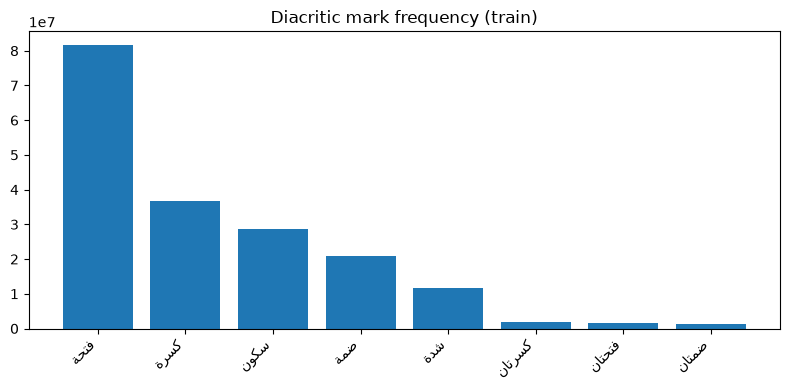

In [10]:
def diacritic_freq_pass(path):
    counter = Counter()
    for chunk in iter_chunks(path, usecols=["output"]):
        for text in chunk["output"]:
            counter.update(ch for ch in text if ch in TASHKEEL)
    return counter


train_diacritic_freq = diacritic_freq_pass(TRAIN_PATH)
diac_df = pd.DataFrame(
    [(araby.name(ch, ch), ch, cnt) for ch, cnt in train_diacritic_freq.items()],
    columns=["name", "char", "count"],
).sort_values("count", ascending=False)
display(diac_df)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(diac_df["name"], diac_df["count"])
ax.set_xticklabels(diac_df["name"], rotation=45, ha="right")
ax.set_title("Diacritic mark frequency (train)")
plt.tight_layout()
plt.show()


## 6. Book/filename breakdown

In [11]:
def filename_pass(path):
    counter = Counter()
    for chunk in iter_chunks(path, usecols=["filename"]):
        counter.update(chunk["filename"])
    return counter


train_filename_counts = filename_pass(TRAIN_PATH)
book_counts_df = pd.DataFrame(
    train_filename_counts.items(), columns=["filename", "n_rows"]
).sort_values("n_rows", ascending=False)

print(f"{len(book_counts_df):,} unique books in train.csv")
display(book_counts_df.describe())
display(book_counts_df.head(10))
display(book_counts_df.tail(10))


200 unique books in train.csv


,n_rows
count,200.000000
mean,5213.490000
std,9897.815674
min,1.000000
25%,2.000000
50%,122.500000
75%,6019.500000
max,49538.000000


,filename,n_rows
42,تحفة المحتاج في شرح المنهاج.txt,49538
17,المبسوط.txt,47372
81,رد المحتار.txt,39388
74,نهاية المحتاج إلى شرح المنهاج.txt,39246
32,فتح القدير.txt,38521
1,البحر الرائق شرح كنز الدقائق.txt,37207
28,أسنى المطالب.txt,32489
49,الفتاوى الهندية.txt,31017
64,شرح مختصر خليل للخرشي.txt,29043
41,حاشية الدسوقي على الشرح الكبير.txt,28773


,filename,n_rows
157,الصبر.htm.txt,1
159,ماذا-يعني-أن-تحب-الله-من-كل-قلبك.htm.txt,1
161,سبحوا-الرب.htm.txt,1
162,أنت-حر-الآن.htm.txt,1
164,الآبَ-نَفْسَهُ-يُحِبُّكُمْ.htm.txt,1
166,يوحنا-المعمدان.htm.txt,1
167,من-الذي-له-مفاتيح-الموت.htm.txt,1
168,بعض-الأشياء-التي-تحدث-عندما-يسبح-الناس-الرب.h...,1
169,يَنْبَغِي-أَنْ-يُصَلَّى-كُلَّ-حِينٍ-وَلاَ-يُم...,1
150,لاَ-تَخَافَا-أَنْتُمَا.htm.txt,1


## 7. Train/test leakage check

In [12]:
train_filenames = set(train_filename_counts)
test_filenames = set(test_df["filename"].unique())
overlap = train_filenames & test_filenames

print(f"train books: {len(train_filenames):,}, test books: {len(test_filenames):,}")
print(f"overlap: {len(overlap):,}")
if overlap:
    print(sorted(overlap)[:20])


train books: 200, test books: 1
overlap: 0


## 8. Duplicate detection

In [13]:
def dup_pass(path):
    counter = Counter()
    for chunk in iter_chunks(path, usecols=["output"]):
        for text in chunk["output"]:
            counter[hashlib.md5(text.encode("utf-8")).hexdigest()] += 1
    return counter


train_output_hashes = dup_pass(TRAIN_PATH)
n_dup_rows = sum(c for c in train_output_hashes.values() if c > 1)
n_dup_groups = sum(1 for c in train_output_hashes.values() if c > 1)
print(f"{n_dup_groups:,} distinct duplicated texts, {n_dup_rows:,} rows involved "
      f"({n_dup_rows / train_n_rows:.2%} of train.csv)")

test_output_hashes = {hashlib.md5(t.encode("utf-8")).hexdigest() for t in test_df["output"]}
train_test_dup = test_output_hashes & set(train_output_hashes)
print(f"train/test exact-duplicate texts: {len(train_test_dup):,}")


0 distinct duplicated texts, 0 rows involved (0.00% of train.csv)
train/test exact-duplicate texts: 0


## 9. Outlier / noise detection

Rows that look like noise for a *diacritized* corpus: zero diacritics despite
being in `output`, heavily non-Arabic text, empty/whitespace-only, or
extremely short.


In [14]:
NON_ARABIC_RATIO_THRESHOLD = 0.3
MIN_CHARS = 3


def outlier_pass(path):
    n_no_diacritics = 0
    n_non_arabic_dominant = 0
    n_empty = 0
    n_very_short = 0

    for chunk in iter_chunks(path, usecols=["output"]):
        for text in chunk["output"]:
            stripped = text.strip()
            if not stripped:
                n_empty += 1
                continue
            if len(stripped) < MIN_CHARS:
                n_very_short += 1
            if not any(ch in TASHKEEL for ch in text):
                n_no_diacritics += 1
            non_arabic = sum(1 for ch in stripped if not is_arabic_letter(ch) and ch != " ")
            if non_arabic / len(stripped) > NON_ARABIC_RATIO_THRESHOLD:
                n_non_arabic_dominant += 1

    return n_no_diacritics, n_non_arabic_dominant, n_empty, n_very_short


(train_n_no_diacritics, train_n_non_arabic_dominant,
 train_n_empty_rows, train_n_very_short) = outlier_pass(TRAIN_PATH)

print(f"fully undiacritized rows: {train_n_no_diacritics:,}")
print(f"non-Arabic-dominant rows (>{NON_ARABIC_RATIO_THRESHOLD:.0%}): {train_n_non_arabic_dominant:,}")
print(f"empty/whitespace-only rows: {train_n_empty_rows:,}")
print(f"very short rows (<{MIN_CHARS} chars): {train_n_very_short:,}")


fully undiacritized rows: 1
non-Arabic-dominant rows (>30%): 144
empty/whitespace-only rows: 1
very short rows (<3 chars): 0


## 10. Summary — parameters for preprocessing

In [15]:
summary = {
    "n_rows": int(train_n_rows),
    "n_unique_books": len(train_filename_counts),
    "consistency_match_rate": float(train_n_match / total),
    "char_len_p50": float(char_pcts[0]),
    "char_len_p90": float(char_pcts[1]),
    "char_len_p95": float(char_pcts[2]),
    "char_len_p99": float(char_pcts[3]),
    "char_len_max": float(char_pcts[4]),
    "word_len_p50": float(word_pcts[0]),
    "word_len_p99": float(word_pcts[3]),
    "n_distinct_chars_input": len(train_char_freq),
    "n_non_arabic_range_chars": len(non_arabic),
    "diacritic_class_counts": {row["name"]: int(row["count"]) for _, row in diac_df.iterrows()},
    "train_test_book_overlap": len(overlap),
    "n_duplicate_groups": n_dup_groups,
    "n_duplicate_rows": n_dup_rows,
    "train_test_duplicate_texts": len(train_test_dup),
    "n_fully_undiacritized_rows": train_n_no_diacritics,
    "n_non_arabic_dominant_rows": train_n_non_arabic_dominant,
    "n_empty_rows": train_n_empty_rows,
    "n_very_short_rows": train_n_very_short,
}

import json
print(json.dumps(summary, indent=2, ensure_ascii=False))


{
  "n_rows": 1042698,
  "n_unique_books": 200,
  "consistency_match_rate": 1.0,
  "char_len_p50": 450.0,
  "char_len_p90": 533.0,
  "char_len_p95": 575.0,
  "char_len_p99": 997.0,
  "char_len_max": 6451.0,
  "word_len_p50": 52.0,
  "word_len_p99": 117.0,
  "n_distinct_chars_input": 133,
  "n_non_arabic_range_chars": 92,
  "diacritic_class_counts": {
    "فتحة": 81511518,
    "كسرة": 36767360,
    "سكون": 28763516,
    "ضمة": 21009138,
    "شدة": 11771588,
    "كسرتان": 1938507,
    "فتحتان": 1605225,
    "ضمتان": 1427183
  },
  "train_test_book_overlap": 0,
  "n_duplicate_groups": 0,
  "n_duplicate_rows": 0,
  "train_test_duplicate_texts": 0,
  "n_fully_undiacritized_rows": 1,
  "n_non_arabic_dominant_rows": 144,
  "n_empty_rows": 1,
  "n_very_short_rows": 0
}


**Recommended `preprocess_sadeed_tashkeela.py` parameters, informed by the numbers above:**

- `MAX_CHAR_LEN` = `char_len_p99` (997) — rows longer than this are **dropped**, not truncated, to avoid slicing a sentence mid-word and corrupting the diacritic alignment.
- Character allowlist = Arabic-range characters + whitespace + basic
  punctuation actually observed above threshold count; everything else in
  the non-Arabic-range table is a stripping/dropping candidate.
- Dedup: drop all rows in duplicate groups (`n_duplicate_groups` /
  `n_duplicate_rows` above).
- Rows failing the consistency check, or flagged as
  undiacritized/non-Arabic-dominant/empty/very-short, are dropped.
